# CVEfixes — Data Analysis
Analysis of vulnerability-fixing commits and associated CVE metadata.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

DB_PATH = 'CVEfixes.db'

conn = sqlite3.connect(DB_PATH)
print('Connected to:', DB_PATH)

Connected to: CVEfixes.db


In [2]:
# Date range of the full database (no filter applied)
date_range = pd.read_sql_query("""
    SELECT
        MIN(published_date) AS first_cve,
        MAX(published_date) AS last_cve
    FROM cve
    WHERE published_date IS NOT NULL AND published_date != ''
""", conn)

first = date_range['first_cve'].iloc[0][:10]
last  = date_range['last_cve'].iloc[0][:10]

print(f'Database date range: {first}  →  {last}')

Database date range: 2024-01-01  →  2026-05-05


## Filter configuration
Change `YEAR_FILTER` to restrict the analysis to a different year, or set it to `None` to load all data.

In [3]:
YEAR_FILTER = 2026  # set to None to load all years

## Load data

In [4]:
year_clause = f"AND strftime('%Y', c.published_date) = '{YEAR_FILTER}'" if YEAR_FILTER else ''

df_cve = pd.read_sql_query(f"""
    SELECT *
    FROM cve c
    WHERE 1=1 {year_clause}
""", conn)

print(f'CVE loaded: {len(df_cve):,}')
df_cve.head(3)

CVE loaded: 21,688


,cve_id,published_date,last_modified_date,description,nodes,severity,obtain_all_privilege,obtain_user_privilege,obtain_other_privilege,user_interaction_required,...,cvss3_confidentiality_impact,cvss3_integrity_impact,cvss3_availability_impact,cvss3_base_score,cvss3_base_severity,exploitability_score,impact_score,ac_insuf_info,reference_json,problemtype_json
0,CVE-2025-69412,2026-01-01T00:15:40.797,2026-04-15T00:35:42.020,KDE messagelib before 25.11.90 ignores SSL err...,[],,,,,,...,NONE,LOW,NONE,3.4,LOW,1.6,1.4,,[{'url': 'https://developers.google.com/safe-b...,"[{'description': [{'lang': 'en', 'value': 'CWE..."
1,CVE-2025-69413,2026-01-01T05:16:03.907,2026-01-06T19:27:57.913,"In Gitea before 1.25.2, /api/v1/user has diffe...","[{'nodes': [{'operator': 'OR', 'negate': False...",,,,,,...,LOW,NONE,NONE,5.3,MEDIUM,3.9,1.4,,[{'url': 'https://blog.gitea.com/release-of-1....,"[{'description': [{'lang': 'en', 'value': 'CWE..."
2,CVE-2025-13820,2026-01-01T06:15:45.010,2026-04-15T00:35:42.020,The Comments WordPress plugin before 7.6.40 d...,[],,,,,,...,LOW,NONE,NONE,5.3,MEDIUM,3.9,1.4,,[{'url': 'https://wpscan.com/vulnerability/21b...,[{'description': []}]


In [5]:
year_clause_fixes = f"AND strftime('%Y', c.published_date) = '{YEAR_FILTER}'" if YEAR_FILTER else ''

df_fixes = pd.read_sql_query(f"""
    SELECT f.cve_id, f.hash, f.repo_url
    FROM fixes f
    JOIN cve c ON f.cve_id = c.cve_id
    WHERE 1=1 {year_clause_fixes}
""", conn)

print(f'Fix records loaded: {len(df_fixes):,}')
print(f'Distinct CVEs with fix: {df_fixes["cve_id"].nunique():,}')
print(f'Distinct fix hashes:    {df_fixes["hash"].nunique():,}')
print(f'Distinct repos:         {df_fixes["repo_url"].nunique():,}')
df_fixes.head(3)

Fix records loaded: 3,724
Distinct CVEs with fix: 2,990
Distinct fix hashes:    3,442
Distinct repos:         1,089


,cve_id,hash,repo_url
0,CVE-2025-69412,01adef0482bb3d5c817433db5208620c84a992b3,https://github.com/KDE/messagelib
1,CVE-2025-11157,b2e37ff37953b68ae833f6874ab5bc510a4ca5fb,https://github.com/feast-dev/feast
2,CVE-2026-21428,98048a033a532ff22320ce1d11789f8d5710dfcd,https://github.com/yhirose/cpp-httplib


In [13]:
df_fc = pd.read_sql_query(f"""
    SELECT fc.*
    FROM file_change fc
    WHERE fc.hash IN (
        SELECT f.hash FROM fixes f
        JOIN cve c ON f.cve_id = c.cve_id
        WHERE 1=1 {year_clause_fixes}
    )
""", conn)

df_fc['has_before'] = df_fc['code_before'].notna() & (df_fc['code_before'] != '')
df_fc['has_after']  = df_fc['code_after'].notna()  & (df_fc['code_after']  != '')
df_fc['has_both']   = df_fc['has_before'] & df_fc['has_after']

print(f'File changes loaded:       {len(df_fc):,}')
print(f'  with code_before+after:  {df_fc["has_both"].sum():,}  ({100*df_fc["has_both"].mean():.1f}%)')
df_fc.head(3)

File changes loaded:       17,882
  with code_before+after:  17,882  (100.0%)


,file_change_id,hash,filename,old_path,new_path,change_type,diff,diff_parsed,num_lines_added,num_lines_deleted,code_after,code_before,nloc,complexity,token_count,programming_language,has_before,has_after,has_both
0,133684397706133,54dda041211098730221d0ae20a2f9f9173e7a21,hss-cx-path.c,src/hss/hss-cx-path.c,src/hss/hss-cx-path.c,ModificationType.MODIFY,"@@ -670,7 +670,7 @@ static int hss_ogs_diam_cx...","{'added': [(673, ' ogs_log_hexdump(OGS_LOG_...",1,1,/*\n * Copyright (C) 2019-2025 by Sukchan Lee ...,/*\n * Copyright (C) 2019-2025 by Sukchan Lee ...,1384,242,7583,C,True,True,True
1,73909573309763,465273d13ba5d47b274c38c9d1b07f04859178a1,s11-handler.c,src/sgwc/s11-handler.c,src/sgwc/s11-handler.c,ModificationType.MODIFY,"@@ -167,7 +167,7 @@ void sgwc_s11_handle_creat...","{'added': [(170, ' int rv, i;'), (203, ' ...",167,130,/*\n * Copyright (C) 2019-2023 by Sukchan Lee ...,/*\n * Copyright (C) 2019-2023 by Sukchan Lee ...,1339,202,7497,C,True,True,True
2,103164745536101,4e913d21f2c032b187815f063dbab5ebe65fe83a,types.c,lib/gtp/v2/types.c,lib/gtp/v2/types.c,ModificationType.MODIFY,"@@ -31,7 +31,13 @@ int16_t ogs_gtp2_parse_bear...","{'added': [(34, ''), (35, ' /* Validate IE ...",13,2,/*\n * Copyright (C) 2019 by Sukchan Lee <acet...,/*\n * Copyright (C) 2019 by Sukchan Lee <acet...,703,99,6960,C,True,True,True


In [7]:
df_mc = pd.read_sql_query(f"""
    SELECT mc.*
    FROM method_change mc
    JOIN file_change fc ON mc.file_change_id = fc.file_change_id
    WHERE fc.hash IN (
        SELECT f.hash FROM fixes f
        JOIN cve c ON f.cve_id = c.cve_id
        WHERE 1=1 {year_clause_fixes}
    )
""", conn)

print(f'Method changes loaded:        {len(df_mc):,}')
print(f'  before_change = True:        {(df_mc["before_change"]=="True").sum():,}')
print(f'  before_change = False:       {(df_mc["before_change"]=="False").sum():,}')
df_mc.head(3)

Method changes loaded:        65,208
  before_change = True:        30,298
  before_change = False:       34,910


,method_change_id,file_change_id,name,signature,parameters,start_line,end_line,code,nloc,complexity,token_count,top_nesting_level,before_change
0,165822186319356,133684397706133,hss_ogs_diam_cx_mar_cb,"hss_ogs_diam_cx_mar_cb( struct msg ** msg , st...","['msg', 'avp', 'session', 'opaque', 'act']",345,994,static int hss_ogs_diam_cx_mar_cb(struct msg *...,548,92,3128,0,False
1,91310817973841,133684397706133,hss_ogs_diam_cx_mar_cb,"hss_ogs_diam_cx_mar_cb( struct msg ** msg , st...","['msg', 'avp', 'session', 'opaque', 'act']",345,994,static int hss_ogs_diam_cx_mar_cb(struct msg *...,548,92,3128,0,True
2,118673427182260,73909573309763,sgwc_s11_handle_update_bearer_response,sgwc_s11_handle_update_bearer_response( sgwc_u...,"['sgwc_ue', 's11_xact', 'gtpbuf', 'message']",1028,1164,void sgwc_s11_handle_update_bearer_response(\n...,100,14,562,0,False


In [8]:
df_cwe_class = pd.read_sql_query(f"""
    SELECT cc.cve_id, cc.cwe_id, cw.cwe_name
    FROM cwe_classification cc
    JOIN cwe cw ON cc.cwe_id = cw.cwe_id
    WHERE cc.cve_id IN (
        SELECT cve_id FROM cve c
        WHERE 1=1 {year_clause}
    )
""", conn)

print(f'CWE classifications loaded: {len(df_cwe_class):,}')
df_cwe_class.head(3)

CWE classifications loaded: 26,187


,cve_id,cwe_id,cwe_name
0,CVE-2025-69412,CWE-295,Improper Certificate Validation
1,CVE-2025-69413,CWE-204,Observable Response Discrepancy
2,CVE-2025-13820,NVD-CWE-noinfo,Insufficient Information


## Summary

In [9]:
label = str(YEAR_FILTER) if YEAR_FILTER else 'all years'
fix_hashes = df_fixes['hash'].nunique()
fix_hashes_with_code = df_fc[df_fc['has_both']]['hash'].nunique()

print(f'=== CVEfixes summary — {label} ===')
print(f'CVEs:                          {df_cve["cve_id"].nunique():>8,}')
print(f'CVEs with fix commit:          {df_fixes["cve_id"].nunique():>8,}')
print(f'Fix commits (unique hashes):   {fix_hashes:>8,}')
print(f'Fix commits with code:         {fix_hashes_with_code:>8,}  ({100*fix_hashes_with_code/fix_hashes:.1f}%)')
print(f'File changes:                  {len(df_fc):>8,}')
print(f'Method changes:                {len(df_mc):>8,}')
print(f'Repos with fix commits:        {df_fixes["repo_url"].nunique():>8,}')

=== CVEfixes summary — 2026 ===
CVEs:                            21,688
CVEs with fix commit:             2,990
Fix commits (unique hashes):      3,442
Fix commits with code:            2,219  (64.5%)
File changes:                    17,882
Method changes:                  65,208
Repos with fix commits:           1,089


In [10]:
# Keep only commits that have code_before, code_after AND diff
valid_hashes = df_fc[
    df_fc['has_both'] &
    df_fc['diff'].notna() &
    (df_fc['diff'] != '')
]['hash'].unique()

df_fixes_with_code = df_fixes[df_fixes['hash'].isin(valid_hashes)]

n_repos   = df_fixes_with_code['repo_url'].nunique()
n_commits = df_fixes_with_code['hash'].nunique()

print(f'Repositories: {n_repos:,}')
print(f'Commits:      {n_commits:,}')

Repositories: 737
Commits:      2,219


Commits per repo — mean: 3.0,  median: 1,  max: 395


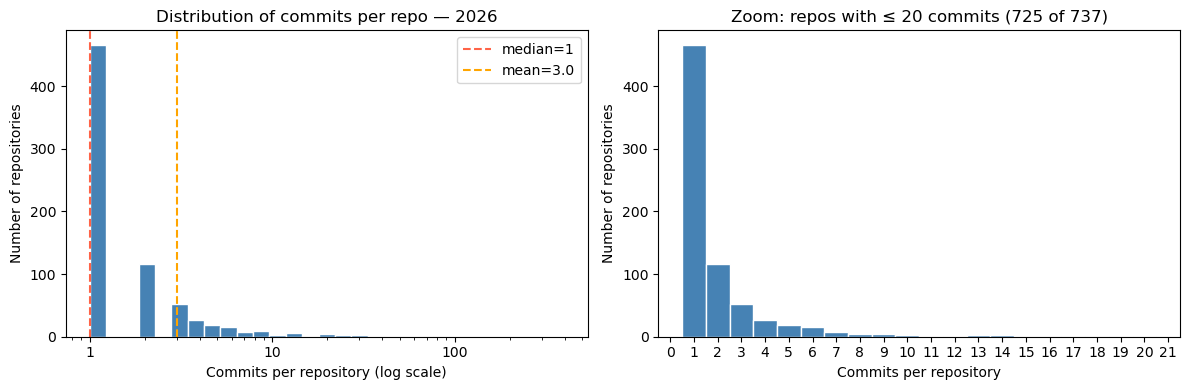

In [11]:
commits_per_repo = (
    df_fixes_with_code.groupby('repo_url')['hash']
    .nunique()
    .rename('n_commits')
    .reset_index()
)

print(f'Commits per repo — mean: {commits_per_repo["n_commits"].mean():.1f},  '
      f'median: {commits_per_repo["n_commits"].median():.0f},  '
      f'max: {commits_per_repo["n_commits"].max()}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
label = str(YEAR_FILTER) if YEAR_FILTER else 'all years'

# Left: full distribution (log scale on x)
ax = axes[0]
bins = np.logspace(0, np.log10(commits_per_repo['n_commits'].max()), 30)
ax.hist(commits_per_repo['n_commits'], bins=bins, color='steelblue', edgecolor='white')
ax.set_xscale('log')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlabel('Commits per repository (log scale)')
ax.set_ylabel('Number of repositories')
ax.set_title(f'Distribution of commits per repo — {label}')
ax.axvline(commits_per_repo['n_commits'].median(), color='tomato', linestyle='--', label=f'median={commits_per_repo["n_commits"].median():.0f}')
ax.axvline(commits_per_repo['n_commits'].mean(),   color='orange',  linestyle='--', label=f'mean={commits_per_repo["n_commits"].mean():.1f}')
ax.legend()

# Right: zoomed on repos with <= 20 commits (most of the distribution)
ax2 = axes[1]
clipped = commits_per_repo[commits_per_repo['n_commits'] <= 20]
ax2.hist(clipped['n_commits'], bins=range(1, 22), color='steelblue', edgecolor='white', align='left')
ax2.set_xlabel('Commits per repository')
ax2.set_ylabel('Number of repositories')
ax2.set_title(f'Zoom: repos with ≤ 20 commits ({len(clipped):,} of {n_repos:,})')
ax2.xaxis.set_major_locator(ticker.MultipleLocator(1))

plt.tight_layout()
plt.show()

Commits per repo — mean: 3.2,  median: 1,  max: 404


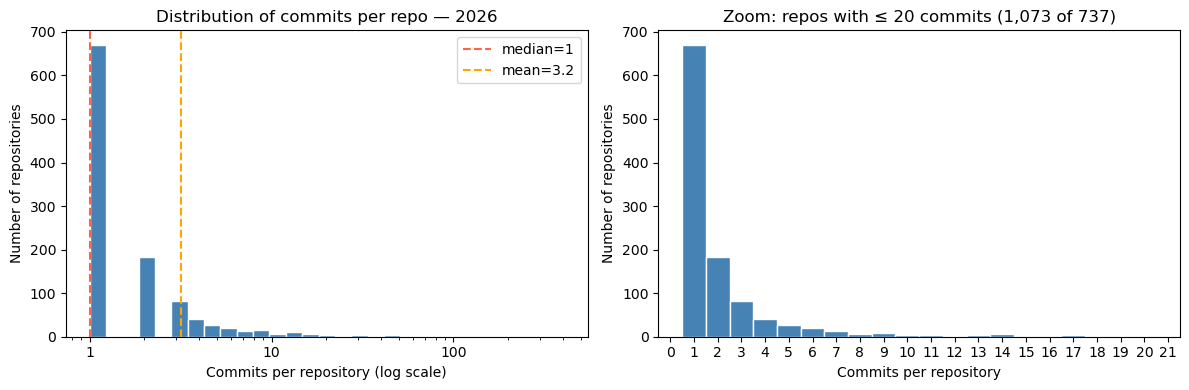

In [12]:
commits_per_repo = (
    df_fixes.groupby('repo_url')['hash']
    .nunique()
    .rename('n_commits')
    .reset_index()
)

print(f'Commits per repo — mean: {commits_per_repo["n_commits"].mean():.1f},  '
      f'median: {commits_per_repo["n_commits"].median():.0f},  '
      f'max: {commits_per_repo["n_commits"].max()}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
label = str(YEAR_FILTER) if YEAR_FILTER else 'all years'

# Left: full distribution (log scale on x)
ax = axes[0]
bins = np.logspace(0, np.log10(commits_per_repo['n_commits'].max()), 30)
ax.hist(commits_per_repo['n_commits'], bins=bins, color='steelblue', edgecolor='white')
ax.set_xscale('log')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlabel('Commits per repository (log scale)')
ax.set_ylabel('Number of repositories')
ax.set_title(f'Distribution of commits per repo — {label}')
ax.axvline(commits_per_repo['n_commits'].median(), color='tomato', linestyle='--', label=f'median={commits_per_repo["n_commits"].median():.0f}')
ax.axvline(commits_per_repo['n_commits'].mean(),   color='orange',  linestyle='--', label=f'mean={commits_per_repo["n_commits"].mean():.1f}')
ax.legend()

# Right: zoomed on repos with <= 20 commits (most of the distribution)
ax2 = axes[1]
clipped = commits_per_repo[commits_per_repo['n_commits'] <= 20]
ax2.hist(clipped['n_commits'], bins=range(1, 22), color='steelblue', edgecolor='white', align='left')
ax2.set_xlabel('Commits per repository')
ax2.set_ylabel('Number of repositories')
ax2.set_title(f'Zoom: repos with ≤ 20 commits ({len(clipped):,} of {n_repos:,})')
ax2.xaxis.set_major_locator(ticker.MultipleLocator(1))

plt.tight_layout()
plt.show()

## Repository size at fix time

Analysis of `repo_analysis.csv`, produced by `cveFixes_repo_size_analyzer.py`:
for every commit with `code_before`, `code_after` and `diff`, the repository was
cloned and measured **at the parent commit** — i.e. the snapshot of the code
just *before* the fix was applied.

The CSV holds one row per `(repo_url, commit)` pair. A repository with several
qualifying commits therefore appears several times, once per snapshot. For the
per-repository distributions below each repo is collapsed to a **single value,
the median of its snapshots**, so that repos with many fix commits do not weigh
more than repos with one.

In [ ]:
CSV_PATH = 'repo_analysis.csv'

df_size = pd.read_csv(CSV_PATH)
print(f'Rows in CSV: {len(df_size):,}')
print(df_size['status'].value_counts().to_string())

# Keep only the rows that were measured successfully.
df_size_ok = df_size[df_size['status'] == 'ok'].copy()

# `repo_url` carries a trailing .git here, unlike the repo_url in the database.
df_size_ok['repo_url'] = df_size_ok['repo_url'].str.replace(r'\.git$', '', regex=True)

print(f'\nMeasured snapshots: {len(df_size_ok):,} '
      f'on {df_size_ok["repo_url"].nunique():,} distinct repositories')
df_size_ok.head(3)

In [ ]:
# One row per repository: the median across its snapshots.
repo_size = (
    df_size_ok.groupby('repo_url')
    .agg(n_snapshots=('commit', 'nunique'),
         n_files=('n_files', 'median'),
         total_lines=('total_lines', 'median'),
         avg_lines_per_file=('avg_lines_per_file', 'median'))
    .reset_index()
)

print(f'Repositories: {len(repo_size):,}')
print(repo_size[['n_files', 'total_lines', 'avg_lines_per_file']]
      .describe()
      .round(1)
      .to_string())

In [ ]:
def plot_distribution(values, xlabel, title, ax):
    """Log-scaled histogram with median and mean markers."""
    bins = np.logspace(np.log10(values.min()), np.log10(values.max()), 30)
    ax.hist(values, bins=bins, color='steelblue', edgecolor='white')
    ax.set_xscale('log')
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Number of repositories')
    ax.set_title(title)
    ax.axvline(values.median(), color='tomato', linestyle='--',
               label=f'median={values.median():,.0f}')
    ax.axvline(values.mean(), color='orange', linestyle='--',
               label=f'mean={values.mean():,.0f}')
    ax.legend()


label = str(YEAR_FILTER) if YEAR_FILTER else 'all years'
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
fig.suptitle(
    f'Repository size at the parent of the fix commit — {label} '
    f'({len(repo_size):,} repositories, median across snapshots)',
    fontsize=11, y=1.03
)

plot_distribution(repo_size['n_files'],
                  'Files per repository (log scale)',
                  'Files per repository', axes[0])
plot_distribution(repo_size['avg_lines_per_file'],
                  'Mean lines per file (log scale)',
                  'Mean lines per file, by repository', axes[1])
plot_distribution(repo_size['total_lines'],
                  'Lines per repository (log scale)',
                  'Lines per repository', axes[2])

plt.tight_layout()
plt.show()

Note on the middle panel: the analyzer stored only `avg_lines_per_file`, the
mean file length **within each repository**, not the length of every individual
file. The middle histogram is therefore the distribution of those per-repo
averages — it answers "how long are the files of a typical repo", not "how long
is a typical file". A true file-level distribution would require re-running the
analyzer with per-file output.